# Load libraries

In [1]:
%reload_ext autoreload
%autoreload 2

import py4DSTEM
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

import h5py
from py4DSTEM import show
from modules_generate_synthethic_4DSTEM import generate_random_colormap
import helper_function   as hf
from sklearn import cluster
from scipy.signal import fftconvolve
from scipy.spatial import distance
from scipy.ndimage import binary_dilation
from skimage.transform import AffineTransform, warp
from matplotlib.colors import ListedColormap, BoundaryNorm

print(py4DSTEM.__version__)
%autoreload 2


0.14.8


In [2]:
def _subtract_dog(frame, min_sigma=1, max_sigma=55):
    """Background removal using difference of Gaussians.
    
    This module is from pyxem repository:
        https://github.com/pyxem/pyxem

    Parameters
    ----------
    frame : NumPy 2D array
    min_sigma : float
    max_sigma : float

    Returns
    -------
    background_removed : Numpy 2D array

    Examples
    --------
    >>> import pyxem.utils._dask as dt
    >>> s = pxm.data.dummy_data.dummy_data.get_cbed_signal()
    >>> s_rem = dt._background_removal_single_frame_dog(s.data[0, 0])

    """
    blur_max = gaussian_filter(frame, max_sigma)
    blur_min = gaussian_filter(frame, min_sigma)
    return np.maximum(np.where(blur_min > blur_max, frame, 0) - blur_max, 0)

# Define custom functions

# Load data

# check output

In [3]:
saved_file_path = "./"
num_grains = 60
syn_2D_scanSpace_map_side_dimension = 128
syn_2D_scanSpace_map = np.load(saved_file_path + "syn_2D_scanSpace_map_side_dim%d_numGrains%d.npy"%(syn_2D_scanSpace_map_side_dimension, num_grains))
custom_cmap = generate_random_colormap(num_colors=num_grains, background_color=(0, 0, 0))


In [4]:
new_4d_tot = np.load(saved_file_path + "multi_crystal_synthetic_4DSTEM_data.npy")
class_label = np.load(saved_file_path + "multi_crystal_synthetic_4DSTEM_data_crystalClass_labels.npy")
direct_beam_kernel = np.load(saved_file_path + "m2_bragg_disks_corThForK80000_dog_sig1_2.00_sig2_8.00_cortThForTemp_5000_direct_beam_kernel.npy")
direct_beam_kernel = direct_beam_kernel[4:int(direct_beam_kernel.shape[0] - 4), 4:int(direct_beam_kernel.shape[1] - 4)]
shifted_direct_beam_kernel = np.fft.fftshift(direct_beam_kernel)
customPROBE = shifted_direct_beam_kernel / np.sum(shifted_direct_beam_kernel)
customPROBE.shape
# datacube_aligned_data = py4DSTEM.DataCube(new_4d_tot)

(120, 120)

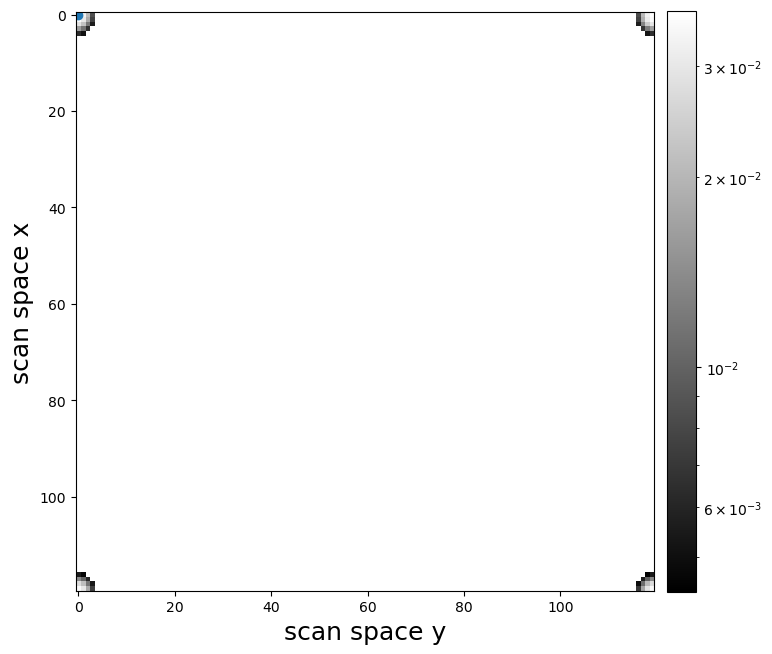

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
# ax.set_title("color map indicating grains", fontsize=20)
im = ax.imshow(customPROBE,  norm = "log", cmap = "gray")
ax.scatter(0,0)
ax.set_xlabel("scan space y", fontsize = 18)
ax.set_ylabel("scan space x", fontsize = 18)
cbar = plt.colorbar(im, ax = ax, fraction=0.0468, pad=0.02)
# cbar.set_label("Grain indices", fontsize=15)
# plt.savefig("grain_color_map.pdf", bbox_inches='tight')
# plt.savefig("grain_color_map.png", bbox_inches='tight')
plt.show()
plt.close()

In [6]:
new_4d_tot[0][0].shape

(120, 120)

In [7]:
real_scan_space_x_size = new_4d_tot.shape[0]
real_scan_space_y_size = new_4d_tot.shape[1]

data_after_difference_of_gaussian = []

for si in range(real_scan_space_x_size):
    r_data_after_difference_of_gaussian = []
    for sj in range(real_scan_space_y_size):
        temp_img_no_nomral = new_4d_tot[si,sj]
        temp_image_dog = _subtract_dog(temp_img_no_nomral , min_sigma = 1, max_sigma = 4)
        r_data_after_difference_of_gaussian.append(temp_image_dog)
    data_after_difference_of_gaussian.append(r_data_after_difference_of_gaussian)    
data_after_difference_of_gaussian = np.array(data_after_difference_of_gaussian)

del new_4d_tot

datacube_aligned_data = py4DSTEM.DataCube(data_after_difference_of_gaussian)

In [8]:
# datacube_aligned_data = py4DSTEM.DataCube(new_4d_tot)

In [9]:
datacube_aligned_data.get_dp_max()
datacube_aligned_data.get_dp_mean()
dp_mean = datacube_aligned_data.get_dp_mean()
dp_max = datacube_aligned_data.get_dp_max()


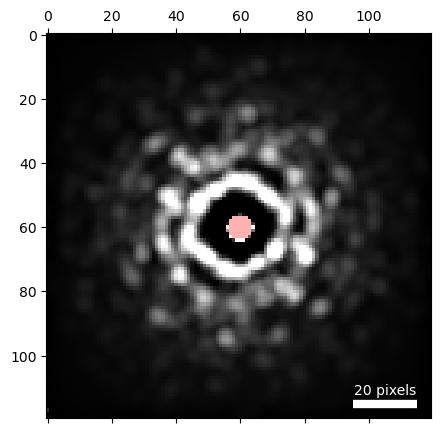

In [10]:
# set the geometry by hand
center = (60,60)
radius = 4


# overlay selected detector position over mean dp
datacube_aligned_data.position_detector(
    mode = 'circle',
    geometry = (
        center,
        radius
    )
)

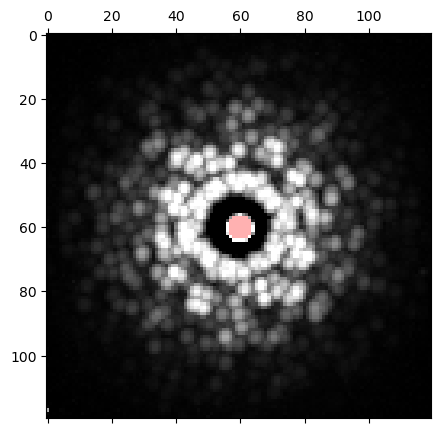

100%|██████████████████████████████████| 16384/16384 [00:00<00:00, 82643.30it/s]










virtual bright field










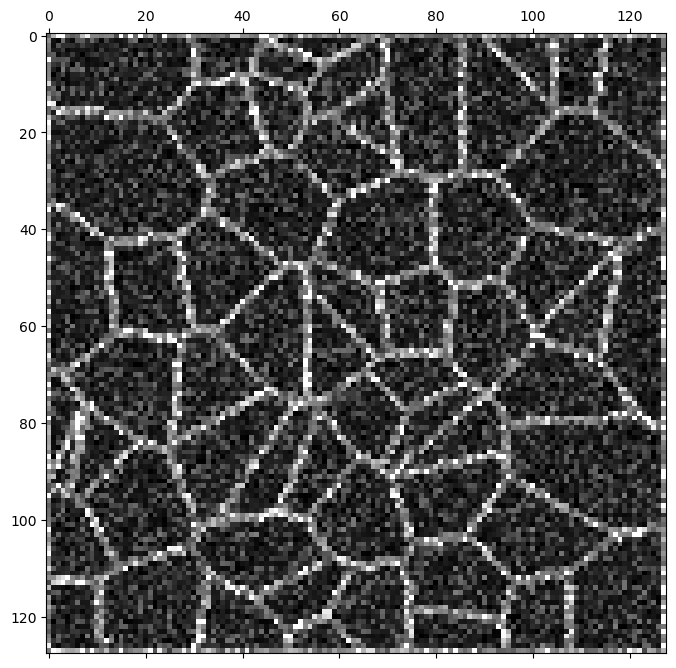

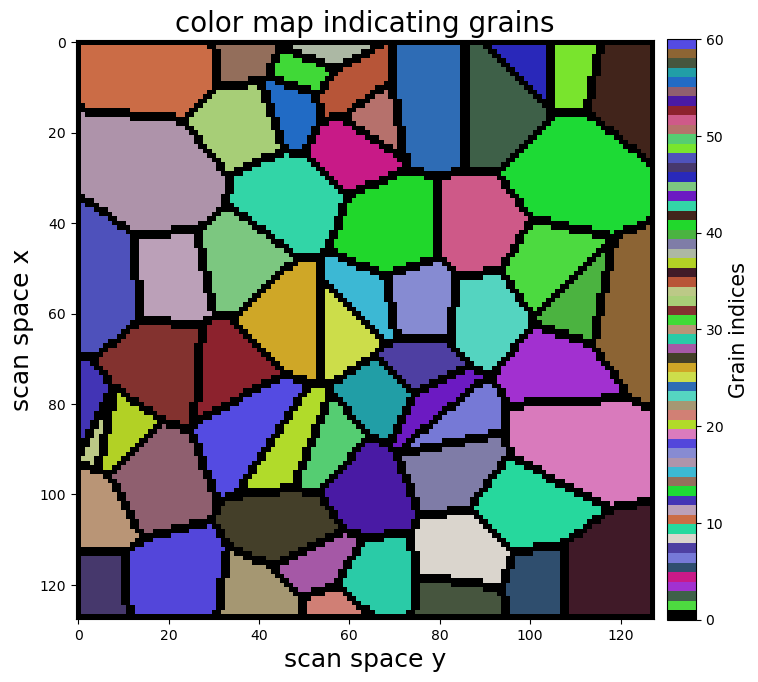

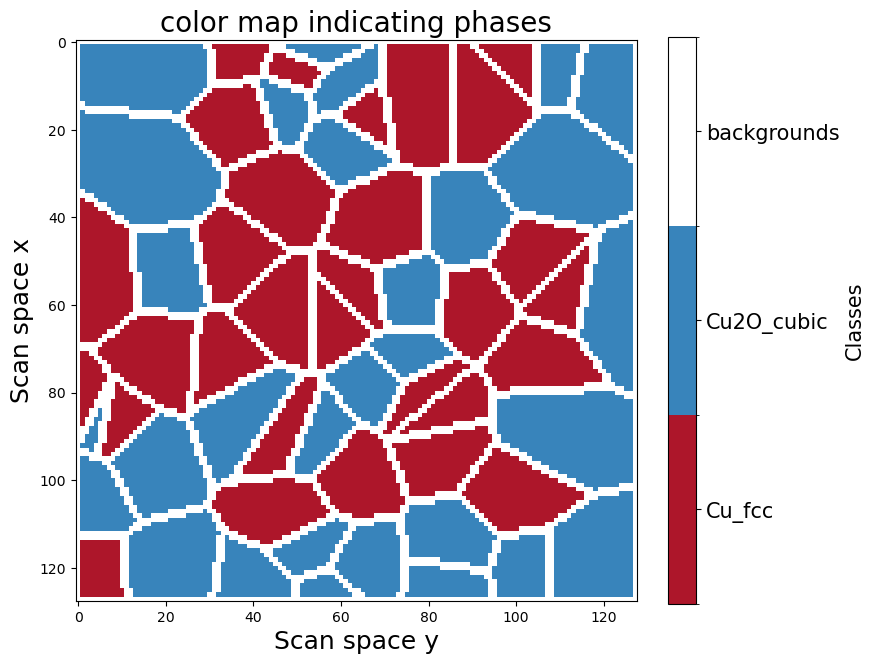

In [11]:

datacube_aligned_data.position_detector(
     data = dp_max,
#     data = datacube[10,30],
    mode = 'circle',
    geometry = (
        center,
        radius
    ),
)
datacube_aligned_data.get_virtual_image(
    mode = 'circle',
    geometry = (center,radius),
    name = 'bright_field',       # the output will be stored in `datacube`'s tree with this name
)
plt.close()
# show
print("\n\n\n\n\n\n\n")

print("virtual bright field")

fig,ax = show( datacube_aligned_data.tree('bright_field'), returnfig=True, figsize=(8, 9), scalebar = False )
fig.savefig("synthetic_4D_STEM_bright_field.png", bbox_inches='tight')

print("\n\n\n\n\n\n\n")
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_title("color map indicating grains", fontsize=20)
im = ax.imshow(syn_2D_scanSpace_map,  cmap =  custom_cmap)
ax.set_xlabel("scan space y", fontsize = 18)
ax.set_ylabel("scan space x", fontsize = 18)
cbar = plt.colorbar(im, ax = ax, fraction=0.0468, pad=0.02)
cbar.set_label("Grain indices", fontsize=15)
plt.savefig("grain_color_map.pdf", bbox_inches='tight')
plt.savefig("grain_color_map.png", bbox_inches='tight')
plt.show()
plt.close()


class_labels = ['Cu_fcc', 'Cu2O_cubic','backgrounds']
tick_positions = [0.5, 1.5, 2.5]

phase_class_color_map = ListedColormap(["#ad162a", "#3884bb", "#ffffff"])
phase_class_color_bounds = np.array([0, 1, 2, 3])
phase_class_color_norm = BoundaryNorm(phase_class_color_bounds, 3)



fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.set_title("color map indicating phases", fontsize=20)
im = ax.imshow(class_label, cmap=phase_class_color_map, norm=phase_class_color_norm)
# Set axis labels
ax.set_xlabel("Scan space y", fontsize=18)
ax.set_ylabel("Scan space x", fontsize=18)
# Add the colorbar with custom ticks and labels
cbar = fig.colorbar(im, ax=ax, fraction=0.0457, ticks=phase_class_color_bounds)
# Set custom ticks and labels on the colorbar
cbar.set_ticks(tick_positions)
cbar.set_ticklabels(class_labels, fontsize=15)
cbar.set_label("Classes", fontsize=15)
plt.savefig("phase_color_map.pdf", bbox_inches='tight')
plt.savefig("phase_color_map.png", bbox_inches='tight')
plt.show()


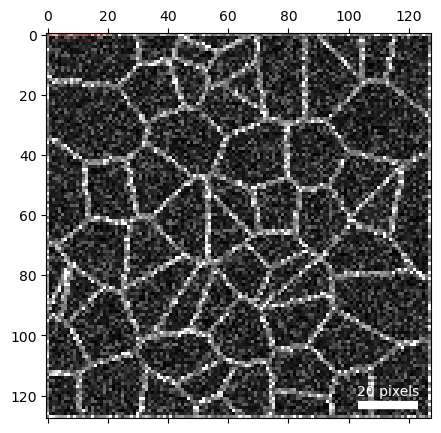

In [12]:
mask = np.zeros(datacube_aligned_data.Rshape,dtype=bool)
mask[0:1,0:20] = 1


show(
    datacube_aligned_data.tree('bright_field'),
    mask = ~mask,
    mask_alpha = 0.667,
    mask_color = 'r'
)

100%|██████████████████████████████████████████| 19/19 [00:00<00:00, 321.93it/s]


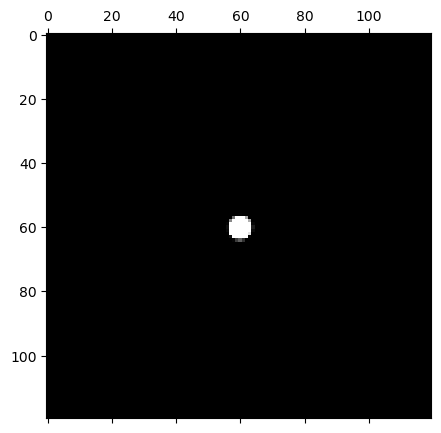

In [13]:
probe = datacube_aligned_data.get_vacuum_probe( ROI=mask )

show(
    probe.probe,
    scaling='none',
    intensity_range='absolute',
    vmin=0,
    vmax=1e5
)

alpha_pr_b,qx0_pr,qy0_pr 2.5383769340344093 60.045893322311635 59.98867868185491


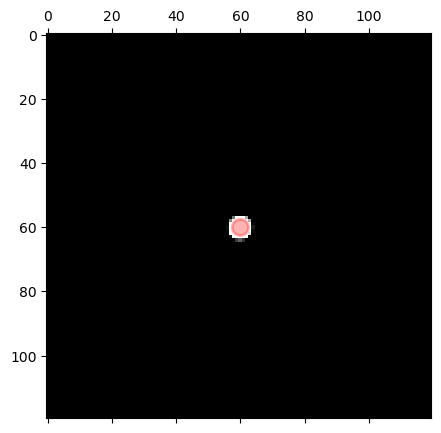

In [14]:

alpha_pr_b,qx0_pr,qy0_pr = datacube_aligned_data.get_probe_size( probe.probe )

print("alpha_pr_b,qx0_pr,qy0_pr", alpha_pr_b,qx0_pr,qy0_pr)


show(
    probe.probe, 
    scaling='none',
    intensity_range='absolute',
    vmin=0,vmax=1e5,
    circle = {
      'center':(qx0_pr,qy0_pr),
      'R': alpha_pr_b,
      'alpha':0.3,
      'fill':True
    }
)

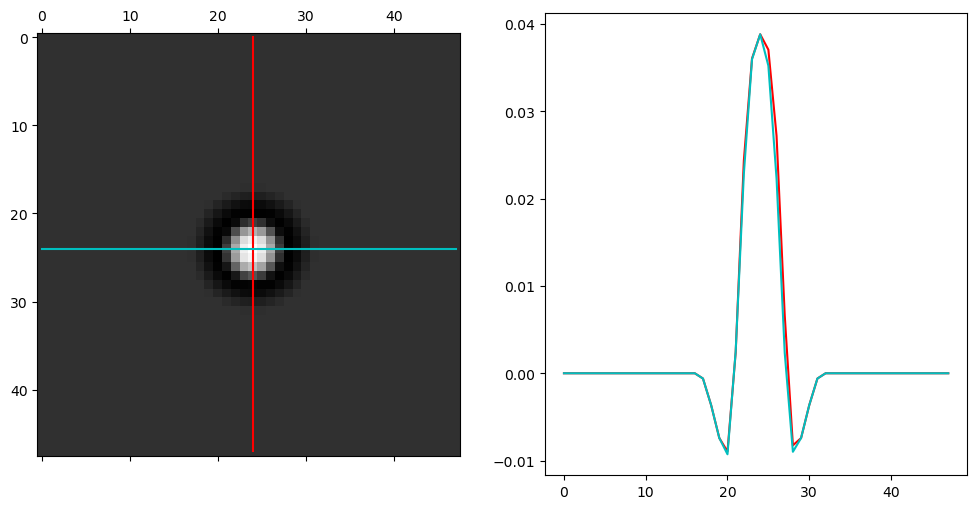

In [15]:
alpha_pr = alpha_pr_b * 1.5
probe.get_kernel(
    mode='sigmoid',
    origin=(qx0_pr,qy0_pr),
    radii=(alpha_pr, 2 * alpha_pr)   # the inner and outer radii of the 'trench'
)

py4DSTEM.visualize.show_kernel(
    probe.kernel,
    R = 24,
    L = 24,
    W = 1
)

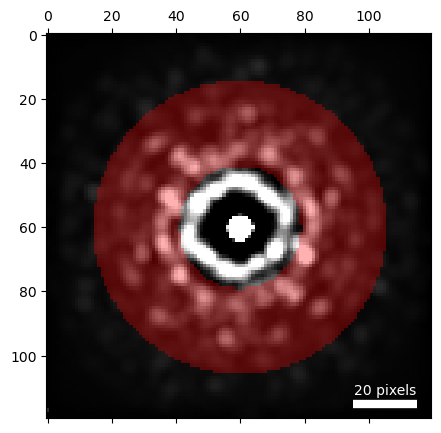

In [13]:

# # set the geometry
# center = qx0_pr,qy0_pr
# r_inner = alpha_pr * 5
# r_outer = alpha_pr * 12
# radii = r_inner,r_outer

# # overlay selected detector position over mean dp
# datacube_aligned_data.position_detector(
#     mode = 'annular',
#     geometry = (
#         center,
#         radii
#     )
# )


100%|██████████████████████████████████| 16384/16384 [00:00<00:00, 64173.31it/s]


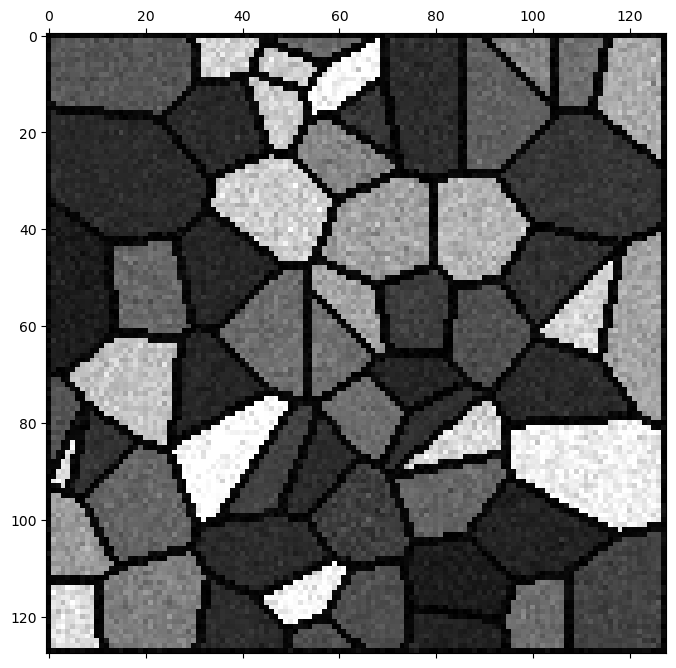

In [14]:
# # compute
# datacube_aligned_data.get_virtual_image(
#     mode = 'annulus',
#     geometry = (center,radii),
#     name = 'annular_dark_field'
# )

# # show
# fig, ax = show(datacube_aligned_data.tree('annular_dark_field'), returnfig=True, figsize=(8, 9), scalebar = False )
# fig.savefig("synthetic_4D_STEM_dark_field.png", bbox_inches='tight')

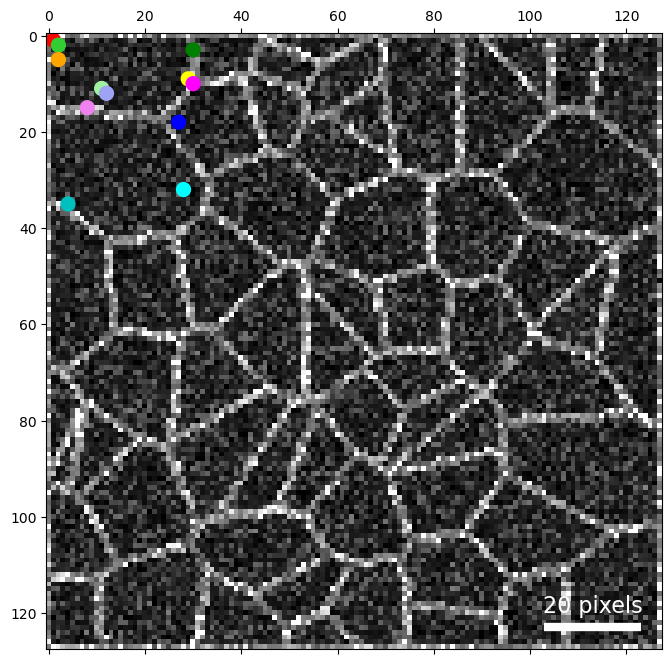

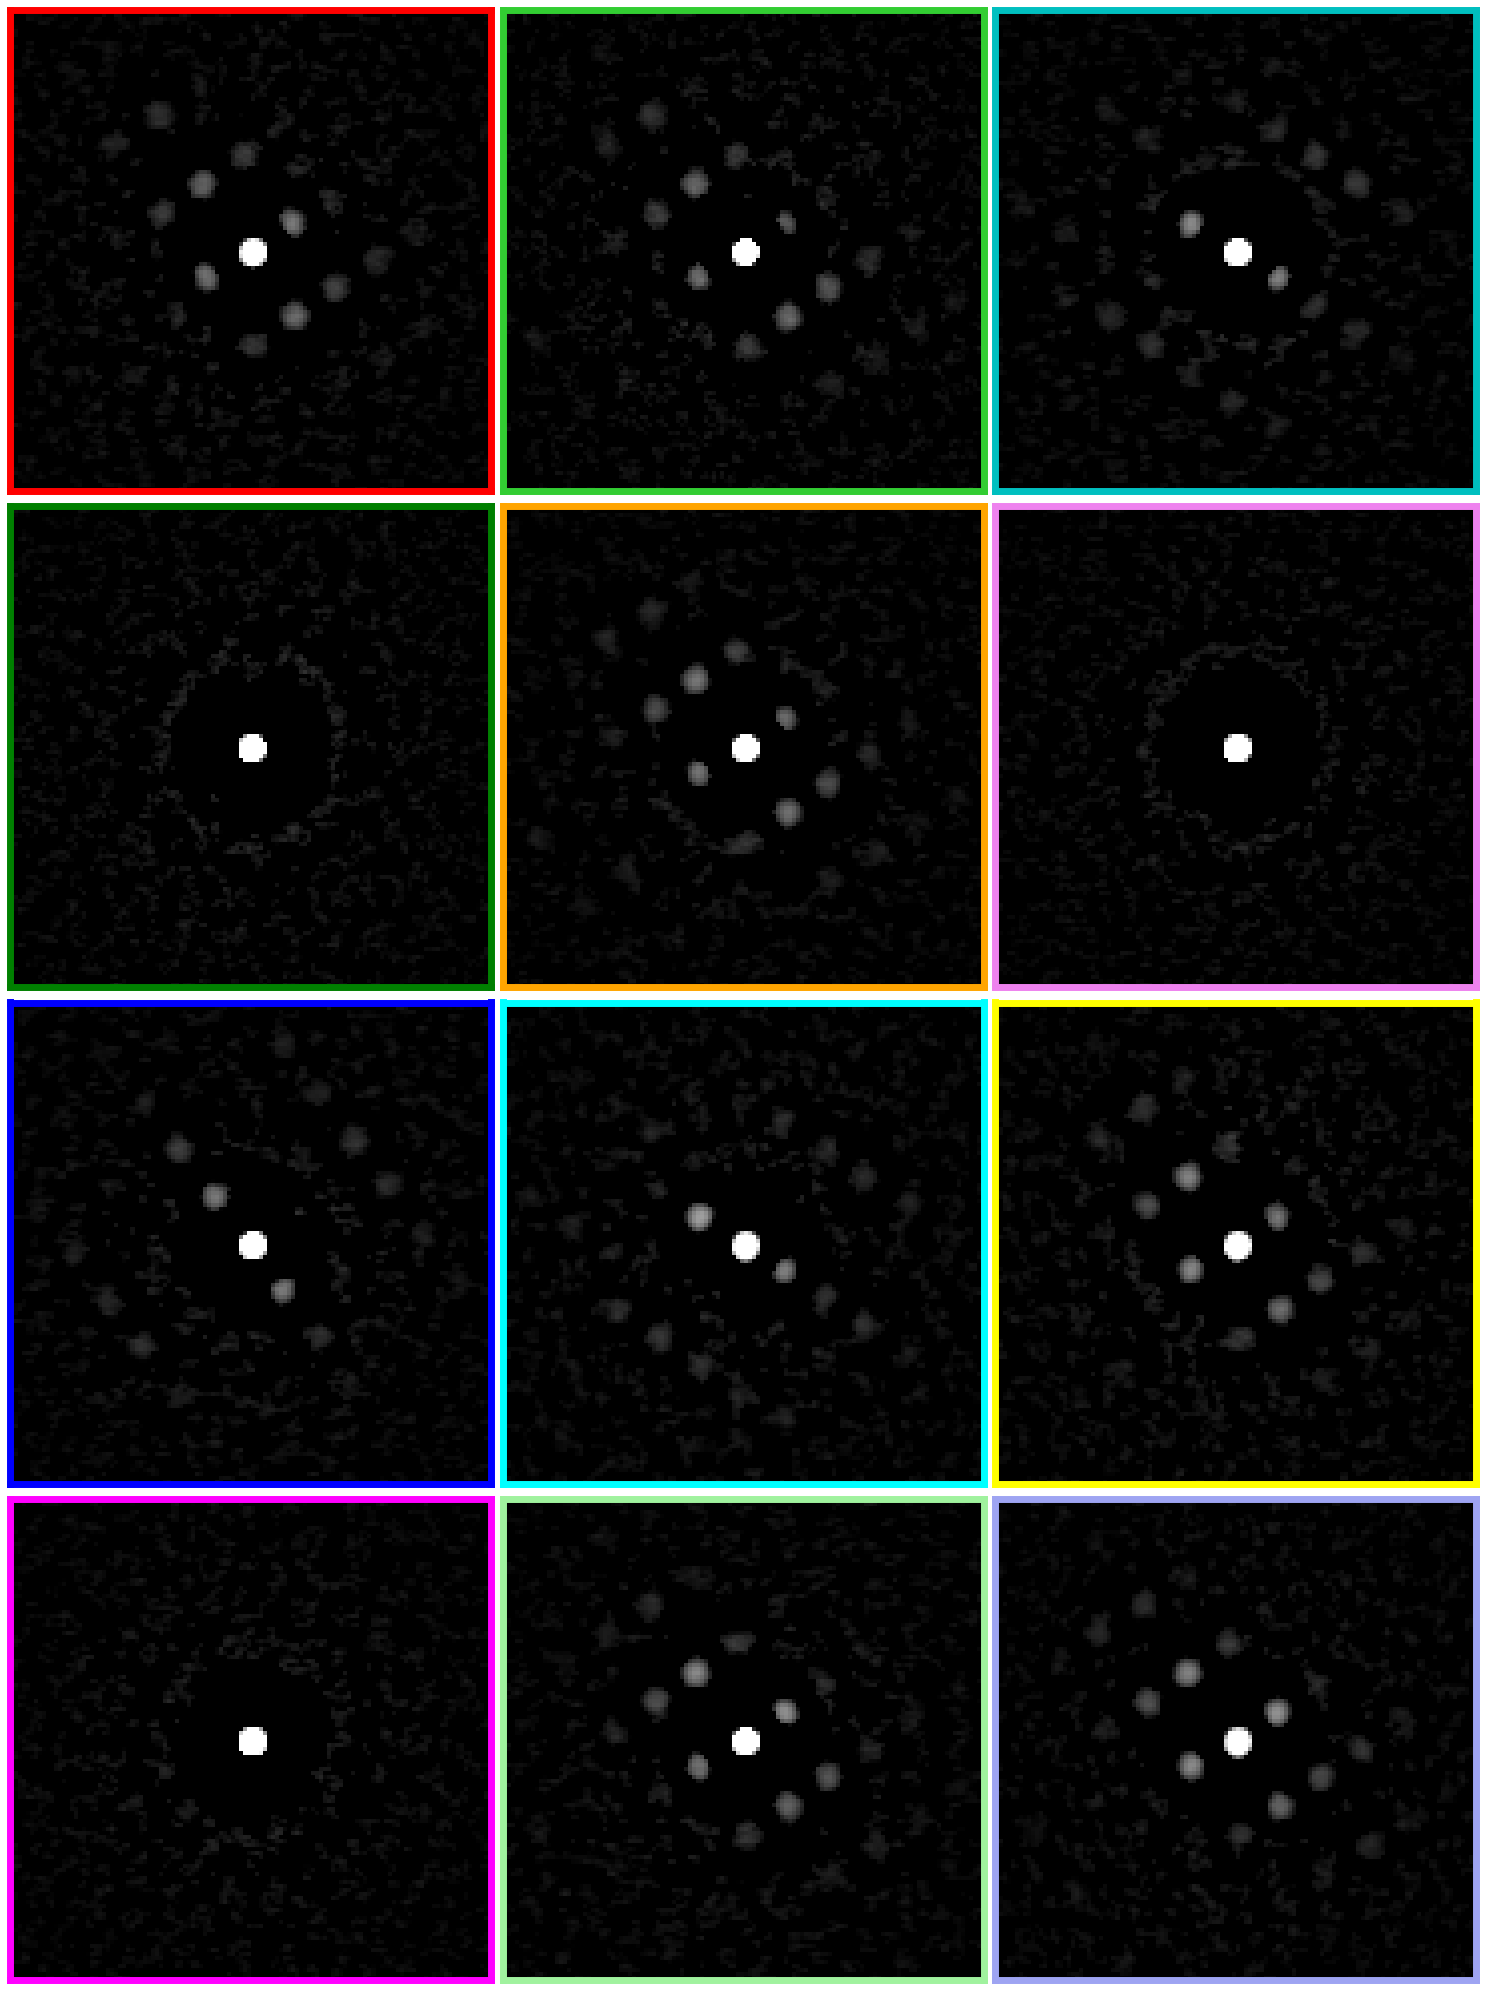

In [16]:
# rxs = 35,15,11,59,32,34,25,247, 122
# rys = 7,15,31,39,20,68,48,50, 131

rxs = 1,2,35,3,5,15, 18,32,9,10, 11, 12
rys = 1,2,4,30,2,  8, 27,28,29,30, 11, 12

# visualize

colors=['r','limegreen','c','g','orange', 'violet', '#0000ff', '#00ffff', '#ffff00', '#ff00ff', '#a0f29e', '#9ea4f2']

# show the selected
# positions in real space
py4DSTEM.visualize.show_points(
    datacube_aligned_data.tree('bright_field'),
    x=rxs,
    y=rys,
    scale = 100,
    pointcolor=colors,
    figsize=(8,8)
)

# show the selected
# diffraction patterns
py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i:datacube_aligned_data[rxs[i],rys[i],:,:],
    H=4,W=3,
    axsize=(5,5),
    intensity_range='absolute',
    vmin=10,
    vmax=1e5,
    scaling='power',
    power=0.5,
    get_bordercolor = lambda i:colors[i],
)

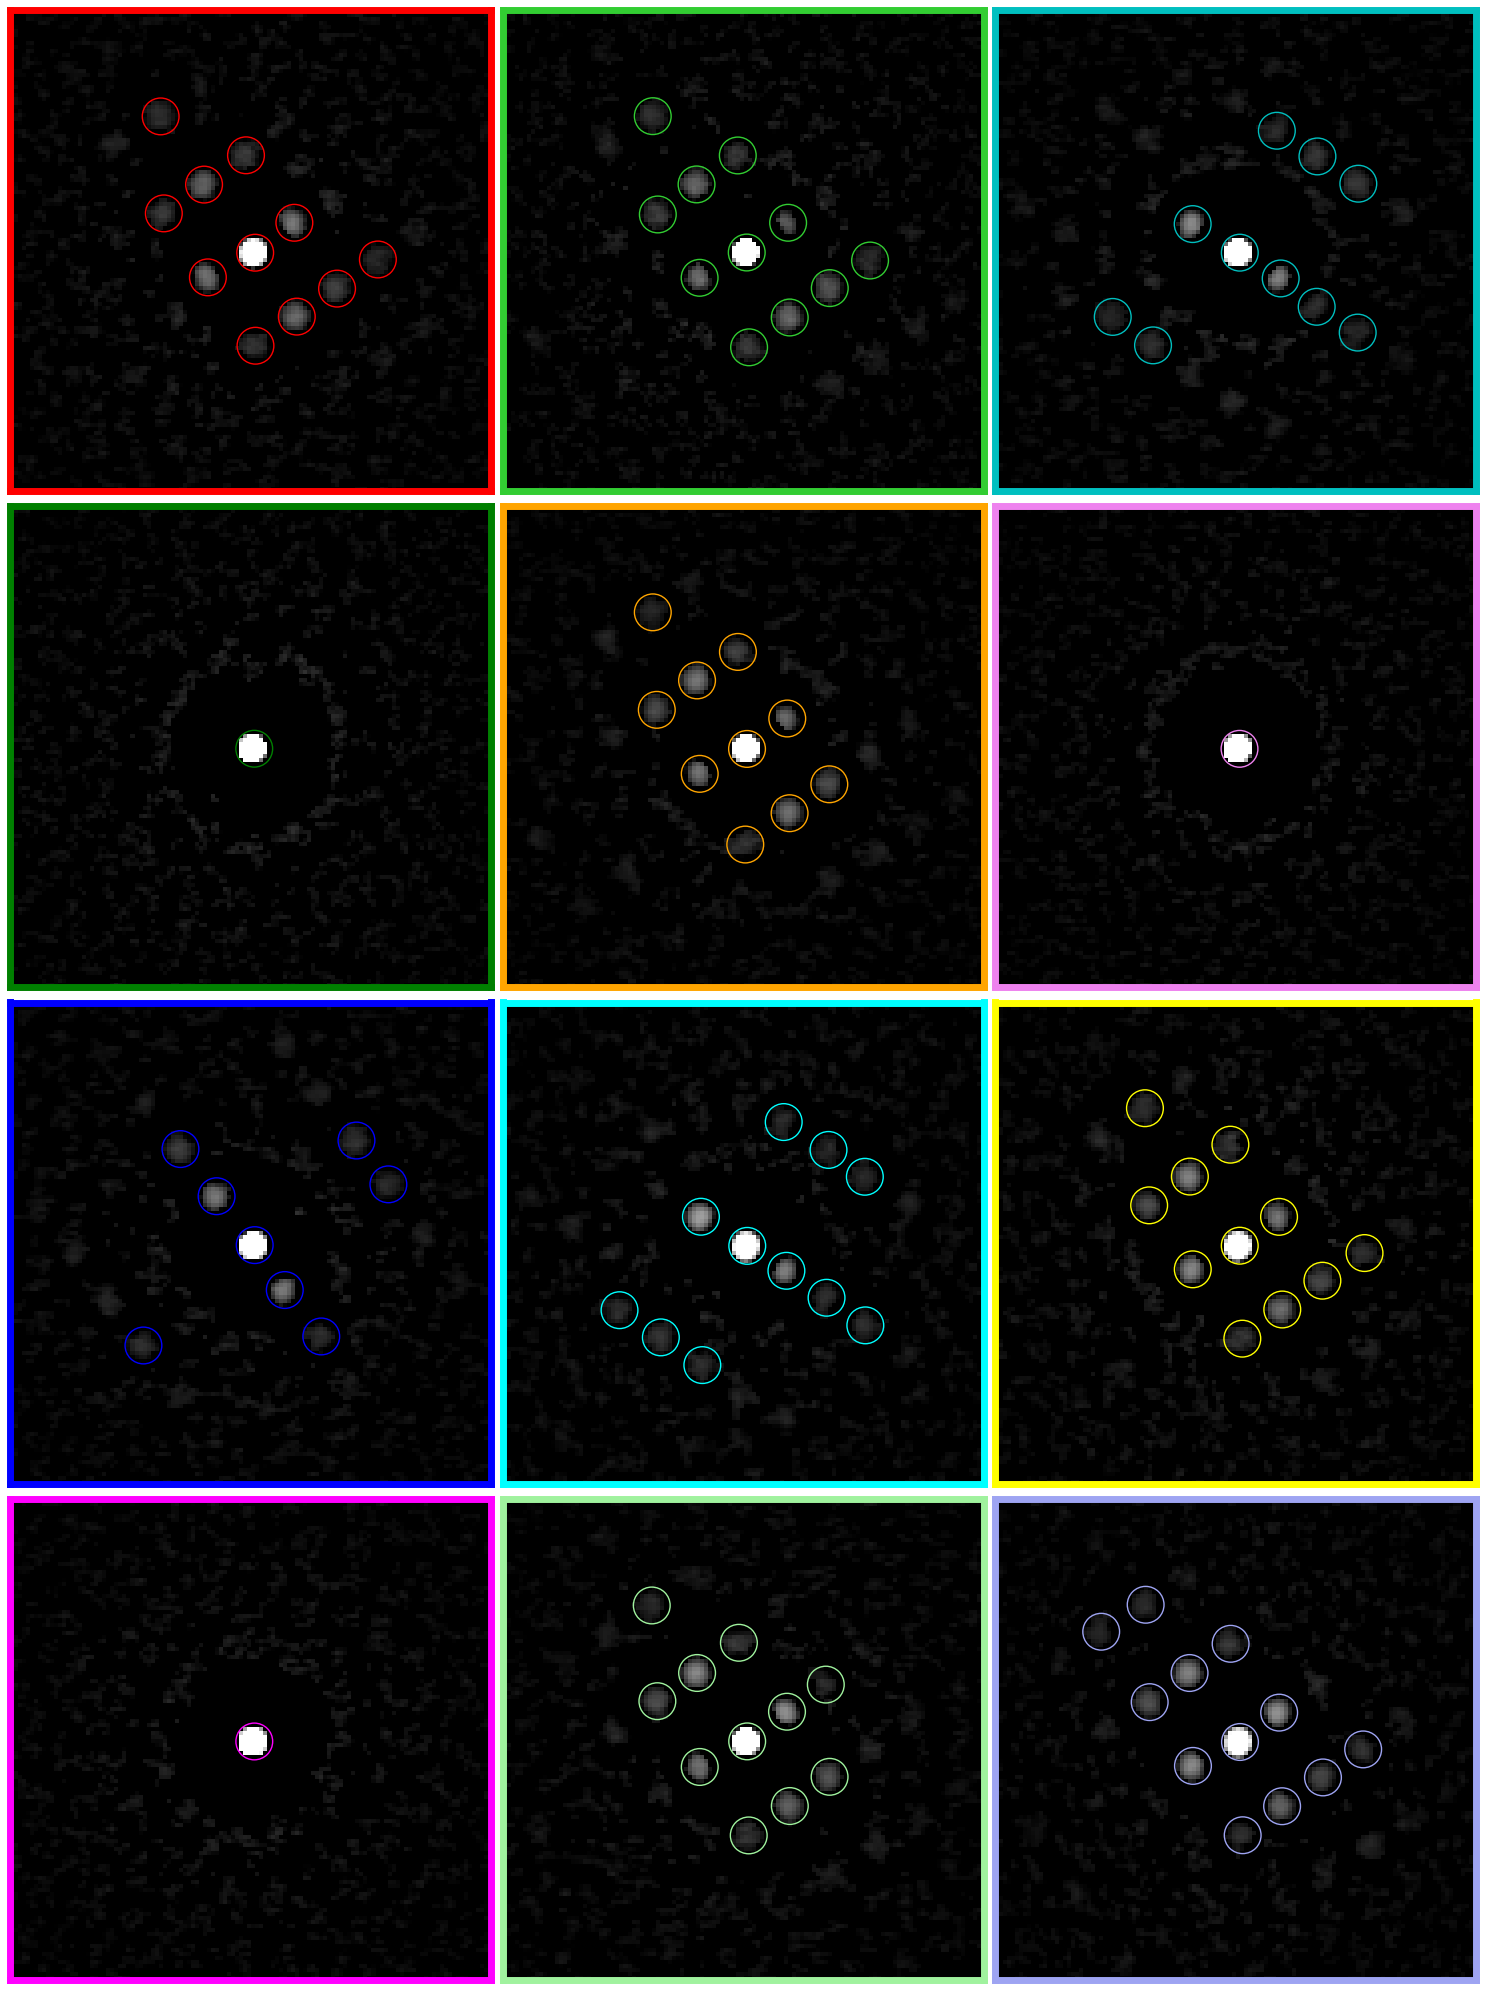

In [17]:

detect_params = {
    'minAbsoluteIntensity':1300,   # intensity threshold
    'minRelativeIntensity': 0.0,   # int. thresh. relative to brightest disk in each pattern
    'minPeakSpacing': 8,         # if two peaks are closer than this (in pixels), remove the dimmer peak
    'edgeBoundary': 8,           # remove peaks within this distance of the edge of the diffraction pattern
    'sigma': 0.1,                  # gaussian blur size to apply to cross correlation before finding maxima
    'maxNumPeaks': 100,          # maximum number of peaks to return, in order of intensity
    'subpixel' : 'poly',         # subpixel resolution method
    'corrPower': 1.0,            # if <1.0, performs a hybrid cross/phase correlation. More sensitive to edges and to noise
#     'CUDA': True,              # if a GPU is configured and cuda dependencies are installed, speeds up calculation 
}


# find disks for selected patterns
disks_selected = datacube_aligned_data.find_Bragg_disks(
    data = (rxs, rys),
    template = customPROBE,
    **detect_params,
)

# show
py4DSTEM.visualize.show_image_grid(
    get_ar = lambda i:datacube_aligned_data[rxs[i],rys[i],:,:],
    H=4, 
    W=3,
    axsize=(5,5),
    intensity_range='absolute',
    vmin=10,
    vmax=1e5,
    scaling='power',
    power=0.5,
    get_bordercolor = lambda i:colors[i],
    get_x = lambda i: disks_selected[i].data['qx'],
    get_y = lambda i: disks_selected[i].data['qy'],
    get_pointcolors = lambda i: colors[i],
    open_circles = True,
    scale = 700,
)


In [18]:
bragg_peaks = datacube_aligned_data.find_Bragg_disks(
    template = customPROBE,
    **detect_params,
)

Finding Bragg Disks: 100%|████████████████| 16.4k/16.4k [00:07<00:00, 2.06kDP/s]


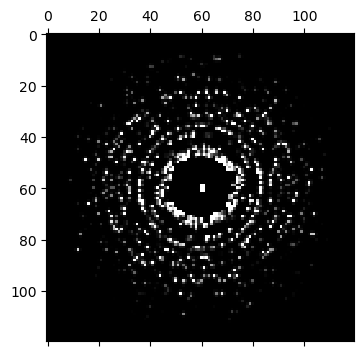

In [19]:
bragg_vector_map_centered = bragg_peaks.get_bvm()

py4DSTEM.show(
    bragg_vector_map_centered,
    figsize = (4,4),
)
# bvm_c = bragg_vector_map_centered

In [20]:
qx0_meas,qy0_meas,mask_meas = bragg_peaks.measure_origin()

In [21]:
bragg_peaks.calibration.get_origin_meas()

(array([[60.12060987, 60.01047231, 59.97689685, ..., 59.97433289,
         60.04519438, 60.09039236],
        [60.08573409, 60.01947155, 60.10946691, ..., 60.17131233,
         60.15655279, 60.11461257],
        [60.14815507, 60.06865338, 59.96970528, ..., 60.09866016,
         60.04528   , 60.14761604],
        ...,
        [60.16354526, 60.03743995, 59.98738392, ..., 60.11327132,
         60.06011366, 60.12199725],
        [60.01211233, 60.09285215, 60.11316677, ..., 60.11870615,
         60.09216812, 59.99495326],
        [60.1301002 , 60.00946457, 59.99356826, ..., 60.04323783,
         60.13542063, 60.11828408]]),
 array([[60.40559068, 60.51675267, 60.43932412, ..., 60.42147772,
         60.52613111, 60.44472275],
        [60.62021612, 60.63846125, 60.61520412, ..., 60.51111843,
         60.59460685, 60.53236234],
        [60.62606567, 60.30735309, 60.37026973, ..., 60.6075266 ,
         60.39583589, 60.39695946],
        ...,
        [60.61645068, 60.5228709 , 60.40663987, ..., 6

In [22]:
q_meas = bragg_peaks.calibration.get_origin_meas()

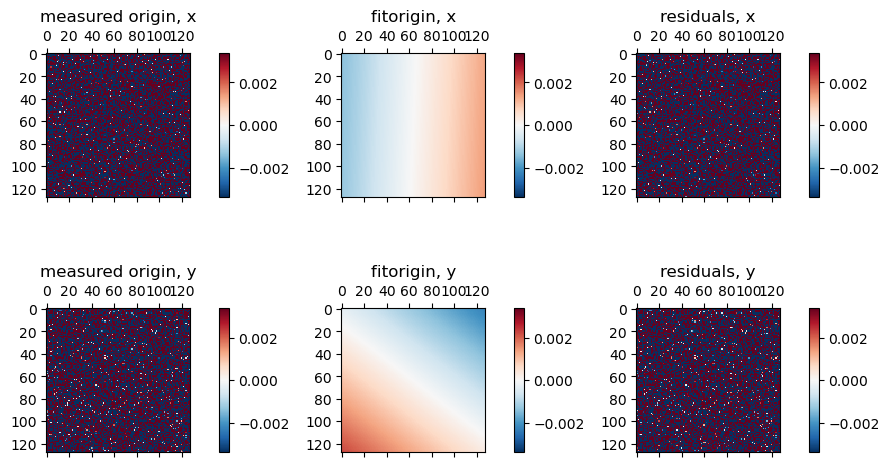

In [23]:
qx0_fit,qy0_fit,qx0_residuals,qy0_residuals = bragg_peaks.fit_origin()

In [24]:
bragg_peaks.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       1
             R_pixel_size:       1
             Q_pixel_units:      pixels
             R_pixel_units:      pixels
             QR_flip:            False
             probe_semiangle:    2.5383769340344093
             qx0_mean:           60.07359156955919
             qy0_mean:           60.48883516985904
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_shift:          2D-array
)

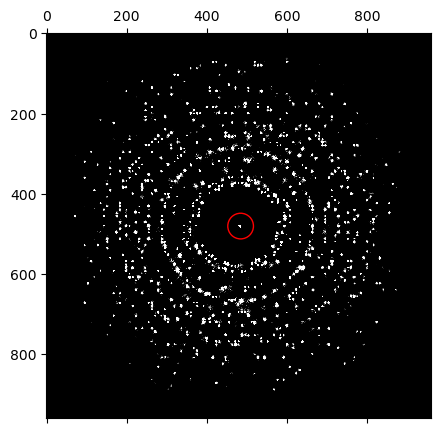

In [25]:
sampling = 8

# compute
bvm = bragg_peaks.histogram(
    #mode='cal',             # 'cal' is the default mode, so this line can be included or left out
    sampling = sampling,
)

# show
# overlay a circle around the center for visualization purposes
show(
    bvm,
    circle={
        'center' : bvm.origin,   # the centered BVM knows where its origin is 
        'R' : 4*sampling,
        'fill' : False,
        'linewidth' : 1
    },
    #vmax=0.9
)

In [26]:
bvm_r = bragg_peaks.histogram( mode='raw', sampling=sampling )
bvm_c = bragg_peaks.histogram( mode='cal', sampling=sampling )

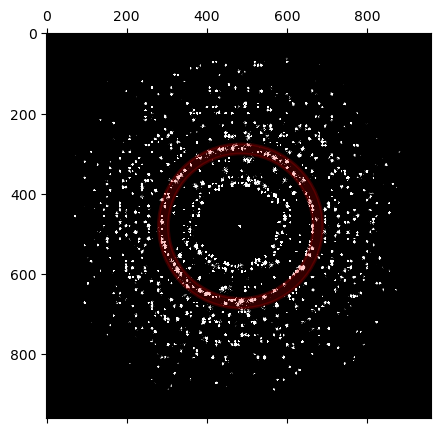

In [27]:
q_range = (180, 205)

py4DSTEM.show(
    bvm_c,
    cmap='gray',
    intensity_range='absolute',
    vmin=0,
    vmax=2e3,
    annulus={
        'center':bvm_c.origin,
        'radii': q_range,'fill':True,'color':'r','alpha':0.2}
)

# q_range = (167, 195)
# py4DSTEM.show(
#     bvm_c,
#     cmap='gray',
#     intensity_range='absolute',
#     vmin=0,
#     vmax=5e3,
#     annulus={
#         'center':bvm_c.origin,
#         'radii': q_range,'fill':True,'color':'r','alpha':0.2}
# )

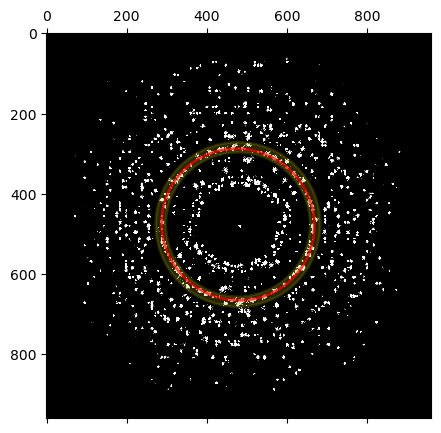

In [28]:
# Fit the elliptical distortions
p_ellipse = py4DSTEM.process.calibration.fit_ellipse_1D(
    bvm_c,
    center = bvm_c.origin,
    fitradii = q_range,
)

# plot the fit
py4DSTEM.visualize.show_elliptical_fit(
    bvm_c,
    q_range,
    p_ellipse,
    cmap='gray',
    intensity_range='absolute',
    vmin=0,
    vmax=1e3,
)

In [29]:
bragg_peaks.calibration.set_p_ellipse(p_ellipse)

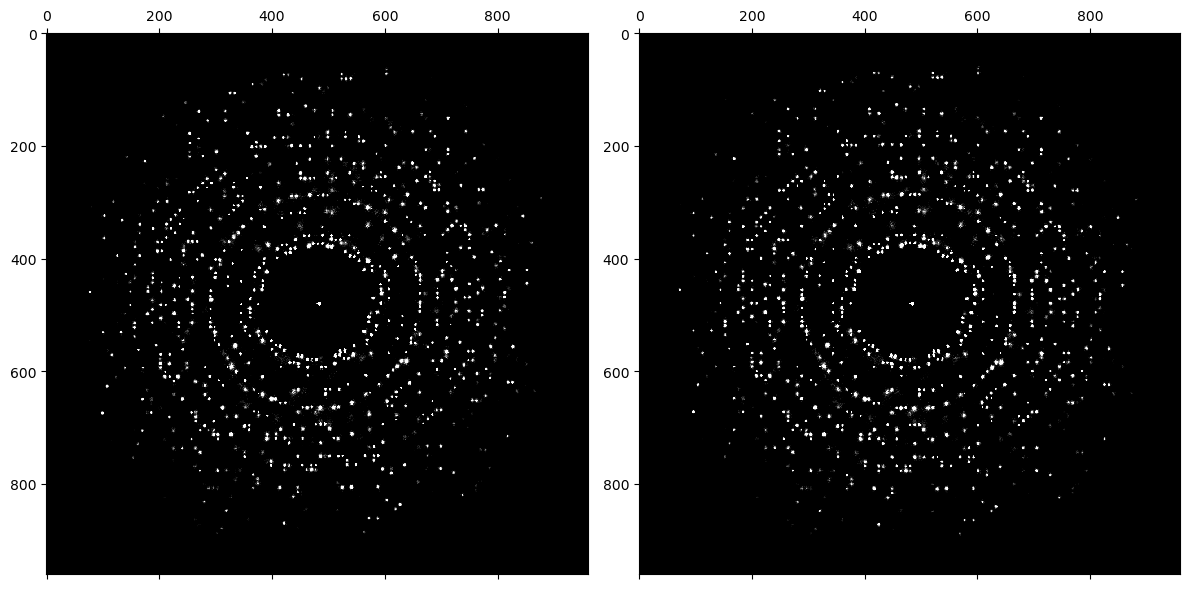

In [30]:
bragg_peaks.setcal()
bvm_e = bragg_peaks.histogram(
    sampling=sampling
)

show([bvm_e, bvm_r],vmax=0.99)

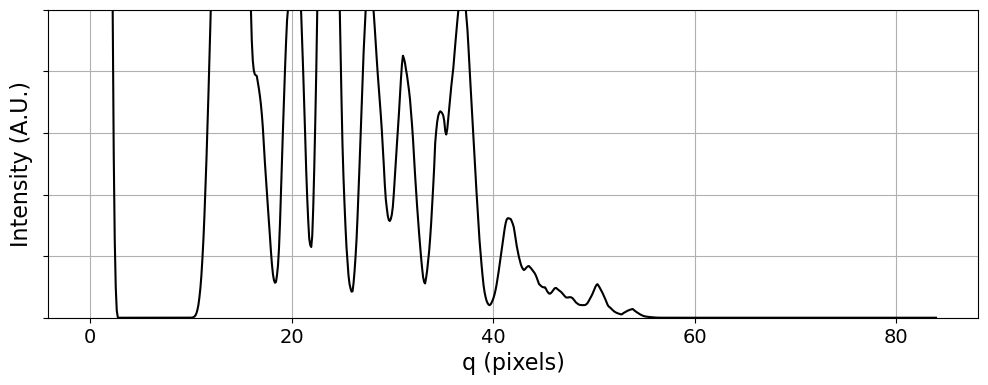

In [31]:
ymax = 1e9

q, intensity_radial = py4DSTEM.process.utils.radial_integral(
    bragg_vector_map_centered,
)

#print("q, intensity_radial", q, intensity_radial)

py4DSTEM.visualize.show_qprofile(
    q = q,
    intensity = intensity_radial * q,
    ymax = ymax,
)

fcc


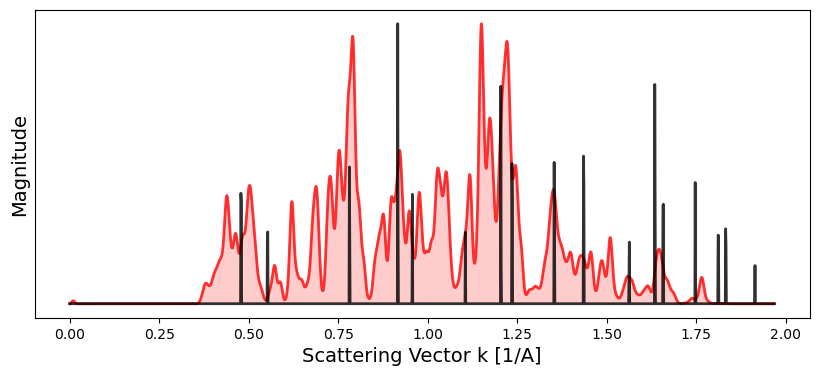

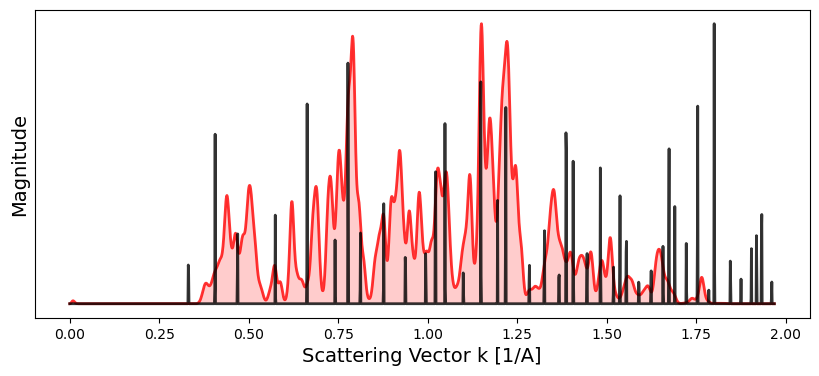

Calibrated pixel size = 0.03314521 A^-1


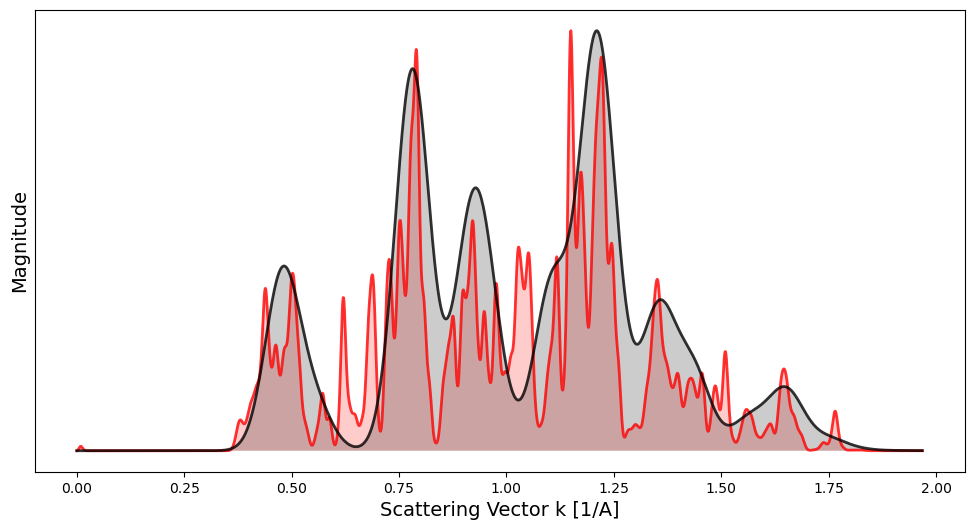

In [32]:
pixel_size_inv_Ang_guess = 0.0328
k_max = pixel_size_inv_Ang_guess * 60

crystal_fcc = py4DSTEM.process.diffraction.Crystal.from_CIF("./Cu_fcc.cif")
crystal_Cu2O = py4DSTEM.process.diffraction.Crystal.from_CIF("./Cu2O_cubic.cif")
crystal_fcc.calculate_structure_factors(
    k_max,
)

crystal_Cu2O.calculate_structure_factors(
    k_max,
)

# crystal_Cu2O.calculate_structure_factors(
#     k_max,
# )

# calibrate
bragg_peaks.calibration.set_Q_pixel_size(pixel_size_inv_Ang_guess)
bragg_peaks.calibration.set_Q_pixel_units('A^-1')
bragg_peaks.setcal()

# show overlay
print("fcc")
crystal_fcc.plot_scattering_intensity(
    bragg_peaks = bragg_peaks,
    bragg_k_power = 2.0
)
plt.show()


crystal_Cu2O.plot_scattering_intensity(
    bragg_peaks = bragg_peaks,
    bragg_k_power = 2.0
)
plt.show()

# print("Cu2O")
# crystal_Cu2O.plot_scattering_intensity(
#     bragg_peaks = bragg_peaks,
#     bragg_k_power = 2.0
# )
# plt.show()

# print("hcp")
# crystal_hcp.plot_scattering_intensity(
#     bragg_peaks = bragg_peaks,
#     bragg_k_power = 2.0
# )
# plt.show()

# print("bcc")
# crystal_bcc.plot_scattering_intensity(
#     bragg_peaks = bragg_peaks,
#     bragg_k_power = 2.0
# )

crystal_fcc.calibrate_pixel_size(
    bragg_peaks = bragg_peaks,
    bragg_k_power = 2.0,
    plot_result = True,
);

In [33]:
bragg_peaks.calibration

Calibration( A Metadata instance called 'calibration', containing the following fields:

             Q_pixel_size:       0.0328
             R_pixel_size:       1
             Q_pixel_units:      A^-1
             R_pixel_units:      pixels
             QR_flip:            False
             probe_semiangle:    2.5383769340344093
             qx0_mean:           60.07359156955919
             qy0_mean:           60.48883516985904
             qx0_meas:           2D-array
             qy0_meas:           2D-array
             origin_meas_mask:   2D-array
             qx0:                2D-array
             qx0_shift:          2D-array
             qy0:                2D-array
             qy0_shift:          2D-array
             a:                  191.60780479379767
             b:                  187.74845213054843
             theta:              -2.1696085448811173
)

In [34]:
filepath_braggdisks_cal = saved_file_path + 'synthetic_4DSTEM_braggdisks.h5'
py4DSTEM.save(
    filepath_braggdisks_cal,
    bragg_peaks,
    mode='o',
)

100%|██████████████████████████████████| 16384/16384 [00:01<00:00, 13745.40it/s]
